### Sieci konwolucyjne (CNN)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from PIL import Image
import os


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


11490434/11490434 [==============================] - 2s 0us/step


In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/5
750/750 [==============================] - 16s 21ms/step - loss: 0.2084 - accuracy: 0.9370 - val_loss: 0.0695 - val_accuracy: 0.9799
Epoch 2/5
750/750 [==============================] - 17s 23ms/step - loss: 0.0592 - accuracy: 0.9812 - val_loss: 0.0604 - val_accuracy: 0.9817
Epoch 3/5
750/750 [==============================] - 18s 25ms/step - loss: 0.0413 - accuracy: 0.9870 - val_loss: 0.0482 - val_accuracy: 0.9860
Epoch 4/5
750/750 [==============================] - 20s 27ms/step - loss: 0.0306 - accuracy: 0.9905 - val_loss: 0.0483 - val_accuracy: 0.9855
Epoch 5/5
750/750 [==============================] - 25s 33ms/step - loss: 0.0242 - accuracy: 0.9926 - val_loss: 0.0403 - val_accuracy: 0.9881


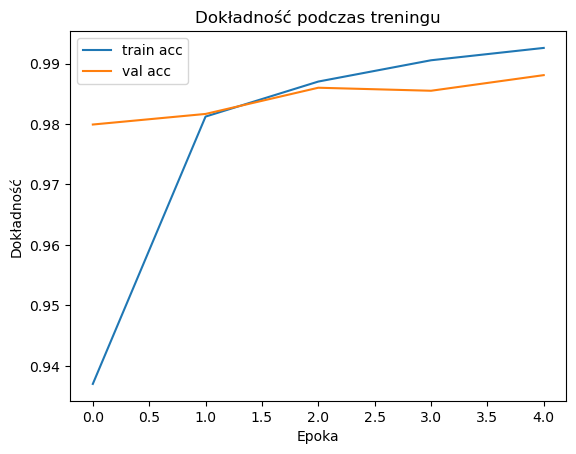

In [4]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Wykresy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.title('Dokładność podczas treningu')
plt.show()

In [14]:
custom_images_dir = './cyfry_testowe/'
for file_name in os.listdir(custom_images_dir):
    if file_name.endswith('.png'):
        img = Image.open(os.path.join(custom_images_dir, file_name)).convert('L').resize((28,28))
        img = np.array(img).astype("float32") / 255.0
        img = img.reshape(1, 28, 28, 1)
        pred = model.predict(img)
        print(f"{file_name} Rozpoznano jako: {np.argmax(pred)}")

1/1 [==============================] - 0s 18ms/step
cztery_1.png Rozpoznano jako: 5
1/1 [==============================] - 0s 17ms/step
cztery_2.png Rozpoznano jako: 4
1/1 [==============================] - 0s 35ms/step
cztery_3.png Rozpoznano jako: 4
1/1 [==============================] - 0s 28ms/step
dwa_1.png Rozpoznano jako: 2
1/1 [==============================] - 0s 18ms/step
dwa_2.png Rozpoznano jako: 3
1/1 [==============================] - 0s 11ms/step
jeden_1.png Rozpoznano jako: 1
1/1 [==============================] - 0s 19ms/step
jeden_2.png Rozpoznano jako: 1
1/1 [==============================] - 0s 16ms/step
osiem_1.png Rozpoznano jako: 8
1/1 [==============================] - 0s 16ms/step
piec_1.png Rozpoznano jako: 5
1/1 [==============================] - 0s 13ms/step
szesc_1.png Rozpoznano jako: 8
1/1 [==============================] - 0s 20ms/step
trzy_1.png Rozpoznano jako: 3
1/1 [==============================] - 0s 27ms/step
trzy_2.png Rozpoznano jako: 3
